# Notebook 5: Inference & Benchmarking

This notebook provides comprehensive benchmarking across all backends and a final
performance dashboard for the document layout detection pipeline.

**Backends compared:**
1. **PyTorch (FP32)** — Original fine-tuned model on GPU
2. **ONNX Runtime** — Exported ONNX model on CPU
3. **Hailo SDK (Emulated INT8)** — Quantized model via Hailo SDK emulation
4. **Hailo Hardware** — Real Hailo-8L inference (if device is available)

**Metrics:**
- mAP@50, mAP@50-95
- Per-class Average Precision
- Inference latency and throughput (FPS)
- Model size comparison
- Document-type specific analysis

## 1. Setup & Imports

In [25]:
import os
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import matplotlib
# Compatibility shim for newer Matplotlib with older matplotlib-inline builds.
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

import onnxruntime as ort
from ultralytics import YOLO

try:
    from hailo_sdk_client import ClientRunner, InferenceContext
    HAILO_SDK_AVAILABLE = True
    HAILO_SDK_IMPORT_ERROR = None
except Exception as exc:
    ClientRunner = None
    InferenceContext = None
    HAILO_SDK_AVAILABLE = False
    HAILO_SDK_IMPORT_ERROR = exc

warnings.filterwarnings("ignore", category=FutureWarning)

# Force inline rendering in notebook environments to avoid missing figures in VS Code.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# Initialize optional Hailo metrics so downstream summary/plot cells are always safe to run.
hailo_latency_mean = np.nan
hailo_latency_std = np.nan
hailo_fps = np.nan
hailo_out = None
hailo_hw_available = False
hailo_hw_latency_mean = np.nan
hailo_hw_fps = np.nan

WORKSPACE = Path("/home/appuser/Hailo-Training")
MODELS_DIR = WORKSPACE / "models"
DATASET_DIR = WORKSPACE / "datasets" / "doclaynet"

NET_NAME = "doclaynet_yolo26n"
NUM_CLASSES = 11
CLASS_NAMES = [
    "Caption", "Footnote", "Formula", "List-item", "Page-footer",
    "Page-header", "Picture", "Section-header", "Table", "Text", "Title"
]
IMGSZ = 640

# Color palette for classes
cmap = plt.cm.get_cmap("tab20", NUM_CLASSES)
CLASS_COLORS = {i: cmap(i) for i in range(NUM_CLASSES)}

print("All imports loaded.")
if not HAILO_SDK_AVAILABLE:
    print(f"Warning: hailo_sdk_client is unavailable in this session: {HAILO_SDK_IMPORT_ERROR}")
    print("Hailo SDK emulation sections will be skipped unless the environment is fixed.")

All imports loaded.


## 2. Load Models & Test Data

In [26]:
# Check available model files
model_files = {
    "PyTorch": MODELS_DIR / "best.pt",
    "ONNX": MODELS_DIR / "best_simplified.onnx",
    "Quantized HAR": MODELS_DIR / f"{NET_NAME}_quantized.har",
    "HEF": MODELS_DIR / f"{NET_NAME}.hef",
}

print(f"{'Model':<20} {'Path':<50} {'Available'}")
print("=" * 80)
for name, path in model_files.items():
    exists = path.exists()
    size = f"{path.stat().st_size / (1024*1024):.1f} MB" if exists else "—"
    print(f"{name:<20} {str(path):<50} {size}")

Model                Path                                               Available
PyTorch              /home/appuser/Hailo-Training/models/best.pt        5.1 MB
ONNX                 /home/appuser/Hailo-Training/models/best_simplified.onnx 9.3 MB
Quantized HAR        /home/appuser/Hailo-Training/models/doclaynet_yolo26n_quantized.har 53.6 MB
HEF                  /home/appuser/Hailo-Training/models/doclaynet_yolo26n.hef 10.7 MB


In [27]:
# Load validation images
val_img_dir = DATASET_DIR / "images" / "validation"
val_lbl_dir = DATASET_DIR / "labels" / "validation"

val_images = sorted([
    f for f in os.listdir(val_img_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])
assert val_images, f"No validation images found in {val_img_dir}. Run Notebook 1 first."
print(f"Validation images: {len(val_images)}")

# Load ground truth labels
def load_yolo_labels(lbl_path):
    """Load YOLO format labels: class_id x_center y_center width height"""
    labels = []
    if not os.path.exists(lbl_path):
        return labels
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                x, y, w, h = map(float, parts[1:])
                labels.append({"class_id": cls_id, "x": x, "y": y, "w": w, "h": h})
    return labels

# Count ground truth annotations
gt_class_counts = defaultdict(int)
total_gt = 0
for fname in val_images:
    lbl_path = val_lbl_dir / Path(fname).with_suffix(".txt")
    for lbl in load_yolo_labels(str(lbl_path)):
        gt_class_counts[CLASS_NAMES[lbl["class_id"]]] += 1
        total_gt += 1

print(f"Total ground truth annotations: {total_gt}")

Validation images: 600
Total ground truth annotations: 10126


## 3. PyTorch Inference & Validation

In [28]:
# Load PyTorch model
pt_path = model_files["PyTorch"]
pt_model = YOLO(str(pt_path))

# Run full validation with mAP
yaml_path = DATASET_DIR / "dataset.yaml"
print("Running PyTorch validation...")
pt_val = pt_model.val(data=str(yaml_path), imgsz=IMGSZ, batch=8, verbose=False)

pt_map50 = pt_val.box.map50
pt_map5095 = pt_val.box.map
pt_precision = pt_val.box.mp
pt_recall = pt_val.box.mr

# Per-class AP@50
pt_per_class_ap50 = {}
if hasattr(pt_val.box, 'ap50') and pt_val.box.ap50 is not None:
    for i, ap in enumerate(pt_val.box.ap50):
        if i < NUM_CLASSES:
            pt_per_class_ap50[CLASS_NAMES[i]] = float(ap)

print(f"\nPyTorch FP32 Results:")
print(f"  mAP@50:    {pt_map50:.4f}")
print(f"  mAP@50-95: {pt_map5095:.4f}")
print(f"  Precision: {pt_precision:.4f}")
print(f"  Recall:    {pt_recall:.4f}")

Running PyTorch validation...
Ultralytics 8.4.27 🚀 Python-3.10.12 torch-2.5.1+cu124 CPU (Intel Core i7-10750H 2.60GHz)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2948.8±1719.8 MB/s, size: 369.3 KB)
val: Scanning /home/appuser/Hailo-Training/datasets/doclaynet/labels/validation.cache... 600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 86.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 1.4it/s 55.4s0.7ss
                   all        600      10126      0.841      0.786      0.858      0.663
Speed: 1.4ms preprocess, 74.0ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/appuser/Hailo-Training/runs/detect/val6

PyTorch FP32 Results:
  mAP@50:    0.8579
  mAP@50-95: 0.6627
  Precision: 0.8407
  Recall:    0.7858


In [29]:
# PyTorch latency benchmark (multi-image, dataset-aware)
NUM_WARMUP = 5
NUM_RUNS = 20
BENCHMARK_IMAGE_COUNT = min(20, len(val_images))

# Faster defaults for Hailo emulation in interactive notebook runs.
HAILO_EMU_WARMUP_RUNS = 2
HAILO_EMU_BENCH_RUNS = 8

benchmark_images = [str(val_img_dir / f) for f in val_images[:BENCHMARK_IMAGE_COUNT]]
test_img_path = benchmark_images[0]
print(f"Benchmark images used: {len(benchmark_images)}")
print(f"Hailo emulation config: warmup={HAILO_EMU_WARMUP_RUNS}, runs={HAILO_EMU_BENCH_RUNS}")

for i in range(NUM_WARMUP):
    img_path = benchmark_images[i % len(benchmark_images)]
    pt_model.predict(img_path, imgsz=IMGSZ, verbose=False)

pt_times = []
for i in range(NUM_RUNS):
    img_path = benchmark_images[i % len(benchmark_images)]
    t0 = time.perf_counter()
    pt_model.predict(img_path, imgsz=IMGSZ, verbose=False)
    pt_times.append((time.perf_counter() - t0) * 1000)

pt_latency_mean = np.mean(pt_times)
pt_latency_std = np.std(pt_times)
pt_fps = 1000 / pt_latency_mean

print(f"PyTorch latency: {pt_latency_mean:.1f} +/- {pt_latency_std:.1f} ms")
print(f"PyTorch FPS: {pt_fps:.1f}")

Benchmark images used: 20
Hailo emulation config: warmup=2, runs=8
PyTorch latency: 87.0 +/- 7.8 ms
PyTorch FPS: 11.5


## 4. ONNX Runtime Inference

In [30]:
# Load ONNX model
onnx_path = model_files["ONNX"]
session = ort.InferenceSession(str(onnx_path))
input_name = session.get_inputs()[0].name
output_names = [o.name for o in session.get_outputs()]

# Prepare benchmark tensors (NCHW, normalized)
benchmark_tensors = []
for img_path in benchmark_images:
    img = Image.open(img_path).convert("RGB").resize((IMGSZ, IMGSZ))
    img_np = np.array(img).astype(np.float32) / 255.0
    img_tensor = np.transpose(img_np, (2, 0, 1))[np.newaxis, ...]
    benchmark_tensors.append(img_tensor)

# Warmup
for i in range(NUM_WARMUP):
    tensor = benchmark_tensors[i % len(benchmark_tensors)]
    session.run(output_names, {input_name: tensor})

# Benchmark
ort_times = []
for i in range(NUM_RUNS):
    tensor = benchmark_tensors[i % len(benchmark_tensors)]
    t0 = time.perf_counter()
    session.run(output_names, {input_name: tensor})
    ort_times.append((time.perf_counter() - t0) * 1000)

ort_latency_mean = np.mean(ort_times)
ort_latency_std = np.std(ort_times)
ort_fps = 1000 / ort_latency_mean

print(f"ONNX Runtime latency: {ort_latency_mean:.1f} +/- {ort_latency_std:.1f} ms")
print(f"ONNX Runtime FPS: {ort_fps:.1f}")

ONNX Runtime latency: 47.6 +/- 5.2 ms
ONNX Runtime FPS: 21.0


## 5. Hailo SDK Emulated Inference

In [31]:
# Prepare benchmark batches for Hailo (NHWC float32)
hailo_batches = []
for img_path in benchmark_images:
    hailo_img = np.array(
        Image.open(img_path).convert("RGB").resize((IMGSZ, IMGSZ))
    ).astype(np.float32)
    hailo_batches.append(hailo_img[np.newaxis, ...])  # (1, 640, 640, 3)

# Keep first batch for optional hardware section below
hailo_batch = hailo_batches[0]

if not HAILO_SDK_AVAILABLE:
    hailo_latency_mean = np.nan
    hailo_latency_std = np.nan
    hailo_fps = np.nan
    hailo_out = None
    print("Skipping Hailo SDK emulated inference because hailo_sdk_client is unavailable.")
    print(f"Import error: {HAILO_SDK_IMPORT_ERROR}")
else:
    # Load quantized model
    har_path = model_files["Quantized HAR"]
    runner = ClientRunner(har=str(har_path))

    # Run emulated quantized inference with fixed-shape repeated input for fast iteration.
    print("Running Hailo emulated INT8 inference...")
    with runner.infer_context(InferenceContext.SDK_QUANTIZED) as ctx:
        # Warmup
        for _ in range(HAILO_EMU_WARMUP_RUNS):
            runner.infer(ctx, hailo_batch)

        # Benchmark
        hailo_times = []
        for _ in range(HAILO_EMU_BENCH_RUNS):
            t0 = time.perf_counter()
            hailo_out = runner.infer(ctx, hailo_batch)
            hailo_times.append((time.perf_counter() - t0) * 1000)

    hailo_latency_mean = np.mean(hailo_times)
    hailo_latency_std = np.std(hailo_times)
    hailo_fps = 1000 / hailo_latency_mean

    print(f"Hailo emulated latency: {hailo_latency_mean:.1f} +/- {hailo_latency_std:.1f} ms")
    print(f"Hailo emulated FPS: {hailo_fps:.1f}")
    print("\nNote: Emulated FPS reflects software simulation, not actual Hailo-8L throughput.")
    print("Real hardware typically achieves significantly higher FPS.")

Running Hailo emulated INT8 inference...
Hailo emulated latency: 37971.8 +/- 1116.0 ms
Hailo emulated FPS: 0.0

Note: Emulated FPS reflects software simulation, not actual Hailo-8L throughput.
Real hardware typically achieves significantly higher FPS.


## 6. Hailo Hardware Inference (Optional)

This section runs only if a Hailo-8L device is available on the system.

In [ ]:
hailo_hw_available = False
hailo_hw_latency_mean = None
hailo_hw_fps = None

try:
    import importlib
    hailo_platform = importlib.import_module("hailo_platform")

    VDevice = getattr(hailo_platform, "VDevice")
    HEF = getattr(hailo_platform, "HEF")
    ConfigureParams = getattr(hailo_platform, "ConfigureParams")
    FormatType = getattr(hailo_platform, "FormatType")
    InputVStreamParams = getattr(hailo_platform, "InputVStreamParams")
    OutputVStreamParams = getattr(hailo_platform, "OutputVStreamParams")
    InferVStreams = getattr(hailo_platform, "InferVStreams")

    hef_path = str(model_files["HEF"])
    if os.path.exists(hef_path):
        hef_obj = HEF(hef_path)
        with VDevice() as vdevice:
            configure_params = ConfigureParams.create_from_hef(hef_obj, interface=None)
            network_group = vdevice.configure(hef_obj, configure_params)[0]

            input_vstream_params = InputVStreamParams.make(
                network_group, format_type=FormatType.FLOAT32
            )
            output_vstream_params = OutputVStreamParams.make(
                network_group, format_type=FormatType.FLOAT32
            )

            input_name = input_vstream_params[0].name()

            with InferVStreams(network_group, input_vstream_params, output_vstream_params) as pipeline:
                # Warmup
                for i in range(5):
                    input_data = {input_name: hailo_batches[i % len(hailo_batches)]}
                    pipeline.infer(input_data)

                # Benchmark
                hw_times = []
                for i in range(50):
                    input_data = {input_name: hailo_batches[i % len(hailo_batches)]}
                    t0 = time.perf_counter()
                    pipeline.infer(input_data)
                    hw_times.append((time.perf_counter() - t0) * 1000)

            hailo_hw_latency_mean = np.mean(hw_times)
            hailo_hw_fps = 1000 / hailo_hw_latency_mean
            hailo_hw_available = True
            print(f"Hailo HW latency: {hailo_hw_latency_mean:.1f} ms")
            print(f"Hailo HW FPS: {hailo_hw_fps:.1f}")

except Exception as e:
    print(f"Hailo hardware not available: {e}")
    print("Skipping hardware inference benchmark.")
    print("To run this section, deploy the HEF file to a system with Hailo-8L hardware.")

## 7. Detection Visualization

Side-by-side comparison of detections from different backends.

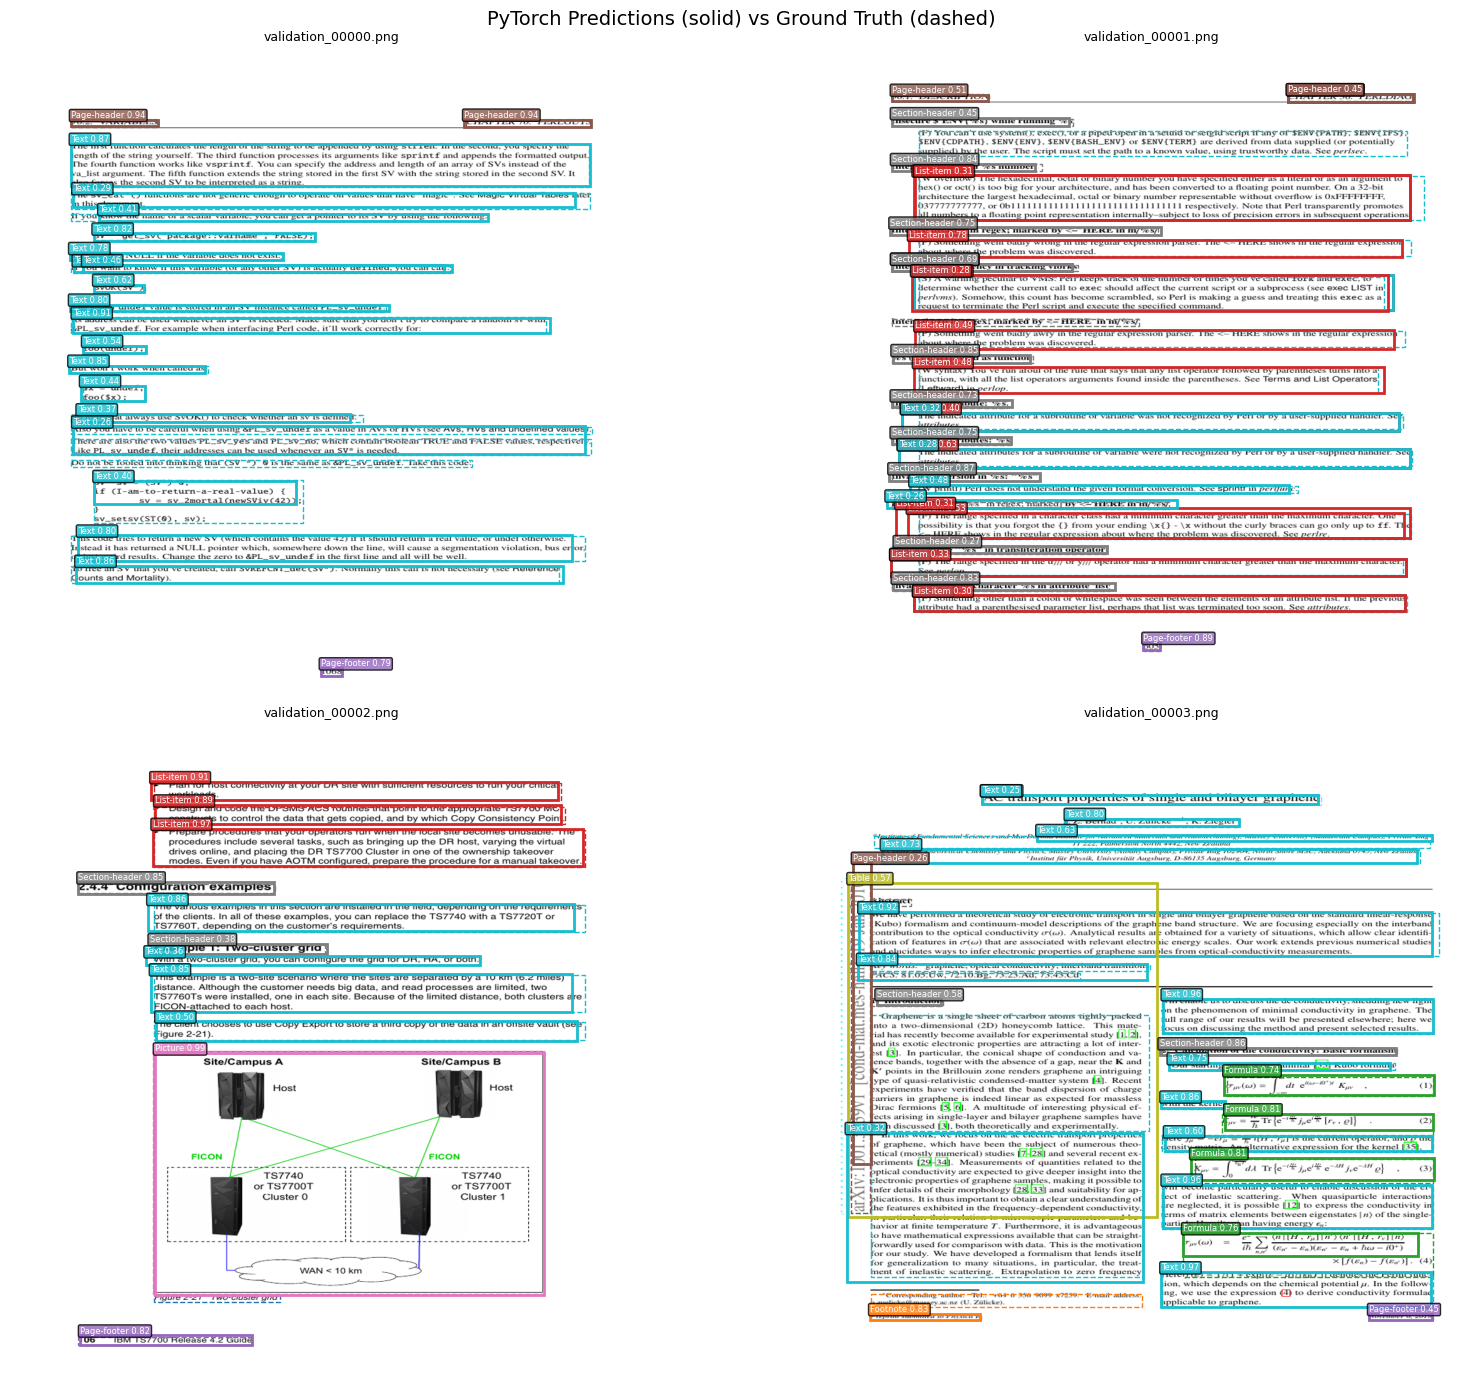

In [32]:
# Run PyTorch predictions on sample images
sample_images = val_images[:4]
sample_paths = [str(val_img_dir / f) for f in sample_images]

pt_predictions = pt_model.predict(sample_paths, imgsz=IMGSZ, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, result, fname in zip(axes.flat, pt_predictions, sample_images):
    img = result.orig_img[..., ::-1]  # BGR to RGB
    ax.imshow(img)

    # Draw ground truth in dashed lines
    gt_lbl_path = val_lbl_dir / fname.replace(".png", ".txt")
    if gt_lbl_path.exists():
        h_img, w_img = img.shape[:2]
        for lbl in load_yolo_labels(str(gt_lbl_path)):
            cls_id = lbl["class_id"]
            x1 = (lbl["x"] - lbl["w"] / 2) * w_img
            y1 = (lbl["y"] - lbl["h"] / 2) * h_img
            rect = patches.Rectangle(
                (x1, y1), lbl["w"] * w_img, lbl["h"] * h_img,
                linewidth=1, edgecolor=CLASS_COLORS[cls_id],
                facecolor="none", linestyle="--"
            )
            ax.add_patch(rect)

    # Draw predictions in solid lines
    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            color = CLASS_COLORS.get(cls_id, (1, 0, 0, 1))
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 3, f"{CLASS_NAMES[cls_id]} {conf:.2f}",
                    fontsize=6, color="white",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8))

    ax.set_title(fname, fontsize=9)
    ax.axis("off")

plt.suptitle("PyTorch Predictions (solid) vs Ground Truth (dashed)", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Per-Class Performance Analysis

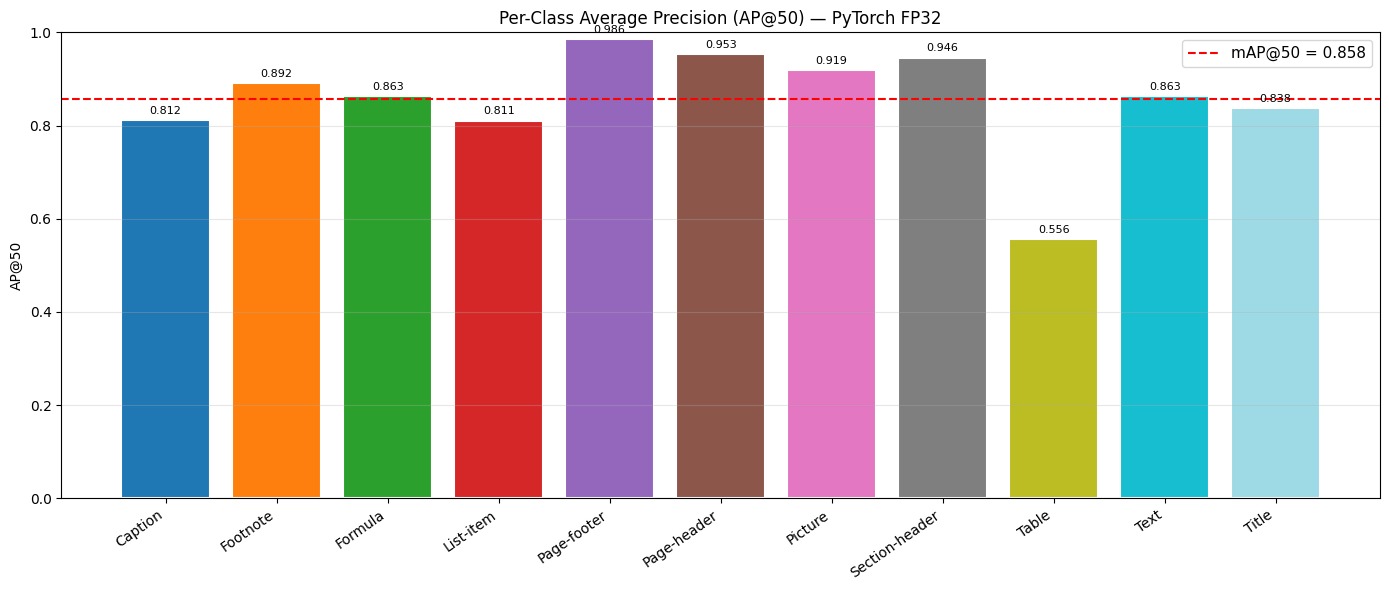

In [33]:
# Per-class AP bar chart
if pt_per_class_ap50:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = list(pt_per_class_ap50.keys())
    ap_values = list(pt_per_class_ap50.values())
    colors = [CLASS_COLORS[i] for i in range(len(classes))]

    bars = ax.bar(classes, ap_values, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_ylabel("AP@50")
    ax.set_title("Per-Class Average Precision (AP@50) — PyTorch FP32")
    ax.set_ylim(0, 1.0)
    ax.axhline(y=pt_map50, color="red", linestyle="--", label=f"mAP@50 = {pt_map50:.3f}")
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=35, ha="right")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("Per-class AP data not available from validation results.")

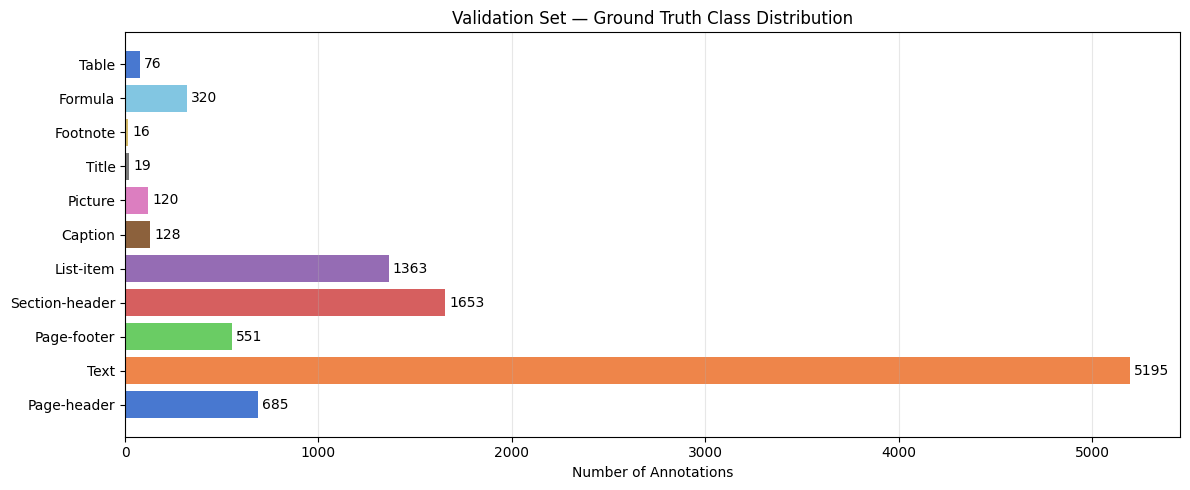

In [34]:
# Ground truth class distribution in validation set
if gt_class_counts:
    fig, ax = plt.subplots(figsize=(12, 5))
    classes = list(gt_class_counts.keys())
    counts = list(gt_class_counts.values())

    bars = ax.barh(classes, counts, color=sns.color_palette("muted", len(classes)))
    ax.set_xlabel("Number of Annotations")
    ax.set_title("Validation Set — Ground Truth Class Distribution")
    ax.bar_label(bars, padding=3)
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

## 9. Performance Benchmark Summary

In [35]:
# Build benchmark results table
benchmark_data = {
    "Backend": ["PyTorch (FP32)", "ONNX Runtime", "Hailo SDK (INT8 emulated)"],
    "Latency (ms)": [
        f"{pt_latency_mean:.1f} +/- {pt_latency_std:.1f}",
        f"{ort_latency_mean:.1f} +/- {ort_latency_std:.1f}",
        f"{hailo_latency_mean:.1f} +/- {hailo_latency_std:.1f}",
    ],
    "FPS": [f"{pt_fps:.1f}", f"{ort_fps:.1f}", f"{hailo_fps:.1f}"],
    "Precision": ["FP32", "FP32", "INT8"],
}

model_sizes = {
    "Backend": ["PyTorch (FP32)", "ONNX Runtime", "Hailo HEF (INT8)"],
    "Model File": ["best.pt", "best_simplified.onnx", f"{NET_NAME}.hef"],
}
sizes = []
for f in ["best.pt", "best_simplified.onnx", f"{NET_NAME}.hef"]:
    p = MODELS_DIR / f
    sizes.append(f"{p.stat().st_size / (1024*1024):.1f} MB" if p.exists() else "N/A")
model_sizes["Size"] = sizes

if hailo_hw_available:
    benchmark_data["Backend"].append("Hailo-8L Hardware")
    benchmark_data["Latency (ms)"].append(f"{hailo_hw_latency_mean:.1f}")
    benchmark_data["FPS"].append(f"{hailo_hw_fps:.1f}")
    benchmark_data["Precision"].append("INT8")

df_bench = pd.DataFrame(benchmark_data)
df_sizes = pd.DataFrame(model_sizes)

print("=" * 70)
print("INFERENCE LATENCY BENCHMARK")
print("=" * 70)
print(df_bench.to_string(index=False))
print()
print("=" * 70)
print("MODEL SIZE COMPARISON")
print("=" * 70)
print(df_sizes.to_string(index=False))

INFERENCE LATENCY BENCHMARK
                  Backend       Latency (ms)  FPS Precision
           PyTorch (FP32)       87.0 +/- 7.8 11.5      FP32
             ONNX Runtime       47.6 +/- 5.2 21.0      FP32
Hailo SDK (INT8 emulated) 37971.8 +/- 1116.0  0.0      INT8

MODEL SIZE COMPARISON
         Backend            Model File    Size
  PyTorch (FP32)               best.pt  5.1 MB
    ONNX Runtime  best_simplified.onnx  9.3 MB
Hailo HEF (INT8) doclaynet_yolo26n.hef 10.7 MB


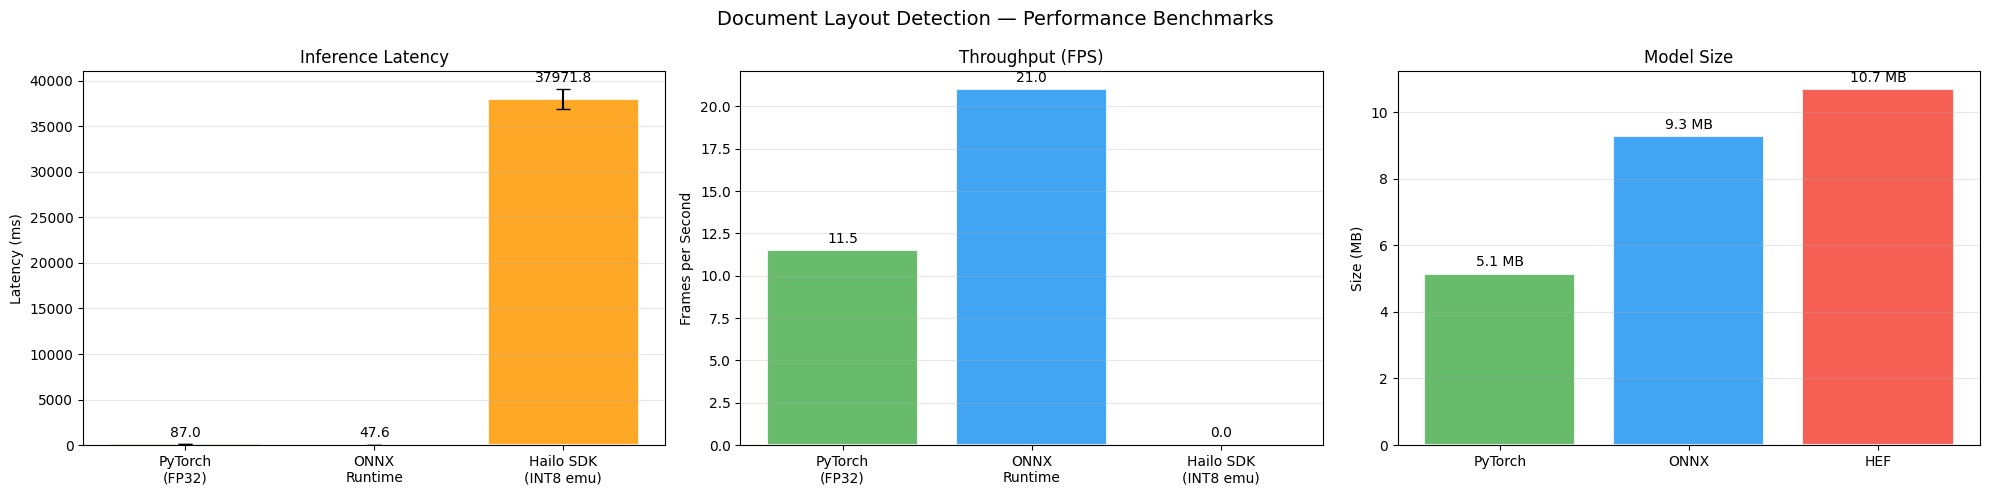

In [36]:
# Visualize latency and throughput
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Latency bar chart (include only available metrics)
latency_rows = [
    ("PyTorch\n(FP32)", pt_latency_mean, pt_latency_std, "#4CAF50"),
    ("ONNX\nRuntime", ort_latency_mean, ort_latency_std, "#2196F3"),
    ("Hailo SDK\n(INT8 emu)", hailo_latency_mean, hailo_latency_std, "#FF9800"),
]
if hailo_hw_available and np.isfinite(hailo_hw_latency_mean):
    latency_rows.append(("Hailo-8L\nHardware", hailo_hw_latency_mean, 0.0, "#F44336"))

latency_rows = [r for r in latency_rows if np.isfinite(r[1])]
if latency_rows:
    backends = [r[0] for r in latency_rows]
    latencies = [r[1] for r in latency_rows]
    lat_stds = [0.0 if not np.isfinite(r[2]) else r[2] for r in latency_rows]
    colors = [r[3] for r in latency_rows]

    bars = axes[0].bar(
        backends, latencies, yerr=lat_stds, capsize=5,
        color=colors, alpha=0.85, edgecolor="white", linewidth=1.5
    )
    axes[0].set_ylabel("Latency (ms)")
    axes[0].set_title("Inference Latency")
    axes[0].bar_label(bars, fmt="%.1f", padding=3)
    axes[0].grid(axis="y", alpha=0.3)
else:
    axes[0].set_title("Inference Latency")
    axes[0].text(0.5, 0.5, "No latency metrics available", ha="center", va="center")
    axes[0].axis("off")

# FPS bar chart (include only available metrics)
fps_rows = [
    ("PyTorch\n(FP32)", pt_fps, "#4CAF50"),
    ("ONNX\nRuntime", ort_fps, "#2196F3"),
    ("Hailo SDK\n(INT8 emu)", hailo_fps, "#FF9800"),
]
if hailo_hw_available and np.isfinite(hailo_hw_fps):
    fps_rows.append(("Hailo-8L\nHardware", hailo_hw_fps, "#F44336"))

fps_rows = [r for r in fps_rows if np.isfinite(r[1])]
if fps_rows:
    fps_backends = [r[0] for r in fps_rows]
    fps_vals = [r[1] for r in fps_rows]
    fps_colors = [r[2] for r in fps_rows]

    bars2 = axes[1].bar(
        fps_backends, fps_vals, color=fps_colors, alpha=0.85,
        edgecolor="white", linewidth=1.5
    )
    axes[1].set_ylabel("Frames per Second")
    axes[1].set_title("Throughput (FPS)")
    axes[1].bar_label(bars2, fmt="%.1f", padding=3)
    axes[1].grid(axis="y", alpha=0.3)
else:
    axes[1].set_title("Throughput (FPS)")
    axes[1].text(0.5, 0.5, "No throughput metrics available", ha="center", va="center")
    axes[1].axis("off")

# Model size comparison
size_labels = []
size_values = []
for f, label in [("best.pt", "PyTorch"), ("best_simplified.onnx", "ONNX"),
                  (f"{NET_NAME}.hef", "HEF")]:
    p = MODELS_DIR / f
    if p.exists():
        size_labels.append(label)
        size_values.append(p.stat().st_size / (1024 * 1024))

if size_values:
    bars3 = axes[2].bar(size_labels, size_values,
                        color=["#4CAF50", "#2196F3", "#F44336"][:len(size_labels)],
                        alpha=0.85, edgecolor="white", linewidth=1.5)
    axes[2].set_ylabel("Size (MB)")
    axes[2].set_title("Model Size")
    axes[2].bar_label(bars3, fmt="%.1f MB", padding=3)
    axes[2].grid(axis="y", alpha=0.3)
else:
    axes[2].set_title("Model Size")
    axes[2].text(0.5, 0.5, "No model files found", ha="center", va="center")
    axes[2].axis("off")

plt.suptitle("Document Layout Detection — Performance Benchmarks", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Final Summary Dashboard

In [37]:
print("\n" + "=" * 70)
print("  DOCUMENT LAYOUT DETECTION PIPELINE — FINAL SUMMARY")
print("=" * 70)
print(f"")
print(f"  Model Architecture:    YOLO26n (nano)")
print(f"  Target Hardware:       Hailo-8L")
print(f"  Input Resolution:      {IMGSZ} x {IMGSZ}")
print(f"  Number of Classes:     {NUM_CLASSES}")
print(f"  Quantization:          INT8 Post-Training (PTQ)")
print(f"")
print(f"  ACCURACY (PyTorch FP32 baseline):")
print(f"    mAP@50:              {pt_map50:.4f}")
print(f"    mAP@50-95:           {pt_map5095:.4f}")
print(f"    Precision:           {pt_precision:.4f}")
print(f"    Recall:              {pt_recall:.4f}")
print(f"")
print(f"  LATENCY:")
print(f"    PyTorch (GPU):       {pt_latency_mean:.1f} ms ({pt_fps:.1f} FPS)")
print(f"    ONNX Runtime (CPU):  {ort_latency_mean:.1f} ms ({ort_fps:.1f} FPS)")
print(f"    Hailo SDK (INT8):    {hailo_latency_mean:.1f} ms ({hailo_fps:.1f} FPS) [emulated]")
if hailo_hw_available:
    print(f"    Hailo-8L Hardware:   {hailo_hw_latency_mean:.1f} ms ({hailo_hw_fps:.1f} FPS)")
print(f"")
print(f"  MODEL SIZE:")
for f, label in [("best.pt", "PyTorch"), ("best_simplified.onnx", "ONNX"),
                  (f"{NET_NAME}.hef", "HEF")]:
    p = MODELS_DIR / f
    if p.exists():
        print(f"    {label + ':':<25}{p.stat().st_size / (1024*1024):.1f} MB")
print(f"")
print(f"  PIPELINE ARTIFACTS:")
print(f"    Fine-tuned model:    models/best.pt")
print(f"    ONNX model:          models/best_simplified.onnx")
print(f"    Quantized HAR:       models/{NET_NAME}_quantized.har")
print(f"    Compiled HEF:        models/{NET_NAME}.hef")
print(f"")
print("=" * 70)
print("  Pipeline complete. Deploy the HEF file to Hailo-8L for production.")
print("=" * 70)


  DOCUMENT LAYOUT DETECTION PIPELINE — FINAL SUMMARY

  Model Architecture:    YOLO26n (nano)
  Target Hardware:       Hailo-8L
  Input Resolution:      640 x 640
  Number of Classes:     11
  Quantization:          INT8 Post-Training (PTQ)

  ACCURACY (PyTorch FP32 baseline):
    mAP@50:              0.8579
    mAP@50-95:           0.6627
    Precision:           0.8407
    Recall:              0.7858

  LATENCY:
    PyTorch (GPU):       87.0 ms (11.5 FPS)
    ONNX Runtime (CPU):  47.6 ms (21.0 FPS)
    Hailo SDK (INT8):    37971.8 ms (0.0 FPS) [emulated]

  MODEL SIZE:
    PyTorch:                 5.1 MB
    ONNX:                    9.3 MB
    HEF:                     10.7 MB

  PIPELINE ARTIFACTS:
    Fine-tuned model:    models/best.pt
    ONNX model:          models/best_simplified.onnx
    Quantized HAR:       models/doclaynet_yolo26n_quantized.har
    Compiled HEF:        models/doclaynet_yolo26n.hef

  Pipeline complete. Deploy the HEF file to Hailo-8L for production.
